# **🚔 Crime Data Analysis (India 2022–2024)**

This project analyzes crime data from 2022 to 2024 to identify patterns, trends, and key insights using Python (Pandas, NumPy, Matplotlib, Seaborn). The goal is to understand crime distribution, victim demographics, and case resolution performance.


**1. Import Required Libraries**

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries Imported Successfully")

Libraries Imported Successfully


**2. Load the dataset**

In [16]:
df = pd.read_csv('/content/crime_dataset_india.csv')
print("Dataset Loaded Successfully")

df.head()

Dataset Loaded Successfully


,Report Number,Date Reported,Date of Occurrence,Time of Occurrence,City,Crime Code,Crime Description,Victim Age,Victim Gender,Weapon Used,Crime Domain,Police Deployed,Case Closed,Date Case Closed
0,1,01-01-2022 11:00,01-01-2022 00:00,01-01-2022 15:06,Lucknow,527,VEHICLE - STOLEN,65,M,NaN,Violent Crime,4,Yes,27-02-2022 11:00
1,2,03-01-2022 22:00,01-01-2022 01:00,01-01-2022 23:44,Hyderabad,580,VEHICLE - STOLEN,71,M,NaN,Violent Crime,11,Yes,15-01-2022 22:00
2,3,03-01-2022 07:00,01-01-2022 02:00,01-01-2022 08:30,Kanpur,114,PUBLIC INTOXICATION,52,M,Other,Other Crime,14,Yes,11-01-2022 07:00
3,4,01-01-2022 23:00,01-01-2022 03:00,02-01-2022 01:56,Delhi,344,FRAUD,77,X,Explosives,Other Crime,6,No,NaN
4,5,03-01-2022 08:00,01-01-2022 04:00,01-01-2022 07:00,Patna,297,FIREARM OFFENSE,44,F,Blunt Object,Fire Accident,8,Yes,09-02-2022 08:00


**3. Basic Data Understanding**

In [17]:
print("Dataset Shape:", df.shape)

print("Columns:")
print(df.columns)

print("Data Info:")
df.info()

print("Statistical Summary")
df.describe()

Dataset Shape: (22616, 14)
Columns:
Index(['Report Number', 'Date Reported', 'Date of Occurrence',
       'Time of Occurrence', 'City', 'Crime Code', 'Crime Description',
       'Victim Age', 'Victim Gender', 'Weapon Used', 'Crime Domain',
       'Police Deployed', 'Case Closed', 'Date Case Closed'],
      dtype='object')
Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22616 entries, 0 to 22615
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Report Number       22616 non-null  int64 
 1   Date Reported       22616 non-null  object
 2   Date of Occurrence  22616 non-null  object
 3   Time of Occurrence  22616 non-null  object
 4   City                22616 non-null  object
 5   Crime Code          22616 non-null  int64 
 6   Crime Description   22616 non-null  object
 7   Victim Age          22616 non-null  int64 
 8   Victim Gender       22616 non-null  object
 9   Weapon Used         193

,Report Number,Crime Code,Victim Age,Police Deployed
count,22616.00000,22616.000000,22616.000000,22616.000000
mean,11308.50000,350.008092,44.684560,10.009064
std,6528.82118,144.733381,20.278858,5.473402
min,1.00000,100.000000,10.000000,1.000000
25%,5654.75000,224.000000,27.000000,5.000000
50%,11308.50000,349.000000,45.000000,10.000000
75%,16962.25000,476.000000,62.000000,15.000000
max,22616.00000,599.000000,79.000000,19.000000


**4. Data Cleaning**

In [18]:
print("Missing Values:")
print(df.isnull().sum())

df.drop_duplicates(inplace=True)

df['Date Reported'] = pd.to_datetime(df['Date Reported'], format='mixed')
df['Date of Occurrence'] = pd.to_datetime(df['Date of Occurrence'], format='mixed')
df['Time of Occurrence'] = pd.to_datetime(df['Time of Occurrence'], format='mixed')
df['Date Case Closed'] = pd.to_datetime(df['Date Case Closed'], format='mixed')

print("After Cleaning:")
df.info()

Missing Values:
Report Number             0
Date Reported             0
Date of Occurrence        0
Time of Occurrence        0
City                      0
Crime Code                0
Crime Description         0
Victim Age                0
Victim Gender             0
Weapon Used            3294
Crime Domain              0
Police Deployed           0
Case Closed               0
Date Case Closed      11315
dtype: int64
After Cleaning:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22616 entries, 0 to 22615
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Report Number       22616 non-null  int64         
 1   Date Reported       22616 non-null  datetime64[ns]
 2   Date of Occurrence  22616 non-null  datetime64[ns]
 3   Time of Occurrence  22616 non-null  datetime64[ns]
 4   City                22616 non-null  object        
 5   Crime Code          22616 non-null  int64         
 6   C

**5. Feature Engineering**

In [19]:
df['Year'] = df['Date of Occurrence'].dt.year
df['Month'] = df['Date of Occurrence'].dt.month_name()
df['Day_Name'] = df['Date of Occurrence'].dt.day_name()
df['Hour'] = df['Time of Occurrence'].dt.hour

df['Resolution_Days'] = (df['Date Case Closed'] - df['Date of Occurrence']).dt.days

df['Age_Group'] = np.where(df['Victim Age'] <= 18, 'Child', np.where(df['Victim Age'] <= 60, 'Adult', 'Senior'))

df.head(10)

,Report Number,Date Reported,Date of Occurrence,Time of Occurrence,City,Crime Code,Crime Description,Victim Age,Victim Gender,Weapon Used,Crime Domain,Police Deployed,Case Closed,Date Case Closed,Year,Month,Day_Name,Hour,Resolution_Days,Age_Group
0,1,2022-01-01 11:00:00,2022-01-01 00:00:00,2022-01-01 15:06:00,Lucknow,527,VEHICLE - STOLEN,65,M,NaN,Violent Crime,4,Yes,2022-02-27 11:00:00,2022,January,Saturday,15,57.0,Senior
1,2,2022-03-01 22:00:00,2022-01-01 01:00:00,2022-01-01 23:44:00,Hyderabad,580,VEHICLE - STOLEN,71,M,NaN,Violent Crime,11,Yes,2022-01-15 22:00:00,2022,January,Saturday,23,14.0,Senior
2,3,2022-03-01 07:00:00,2022-01-01 02:00:00,2022-01-01 08:30:00,Kanpur,114,PUBLIC INTOXICATION,52,M,Other,Other Crime,14,Yes,2022-11-01 07:00:00,2022,January,Saturday,8,304.0,Adult
3,4,2022-01-01 23:00:00,2022-01-01 03:00:00,2022-02-01 01:56:00,Delhi,344,FRAUD,77,X,Explosives,Other Crime,6,No,NaT,2022,January,Saturday,1,NaN,Senior
4,5,2022-03-01 08:00:00,2022-01-01 04:00:00,2022-01-01 07:00:00,Patna,297,FIREARM OFFENSE,44,F,Blunt Object,Fire Accident,8,Yes,2022-09-02 08:00:00,2022,January,Saturday,7,244.0,Adult
5,6,2022-01-01 18:00:00,2022-01-01 05:00:00,2022-01-01 14:54:00,Bangalore,117,DOMESTIC VIOLENCE,12,X,Blunt Object,Violent Crime,2,Yes,2022-01-19 18:00:00,2022,January,Saturday,14,18.0,Child
6,7,2022-03-01 11:00:00,2022-01-01 06:00:00,2022-01-01 20:47:00,Delhi,189,ROBBERY,62,M,Poison,Violent Crime,6,No,NaT,2022,January,Saturday,20,NaN,Senior
7,8,2022-04-01 05:00:00,2022-01-01 07:00:00,2022-01-01 08:50:00,Ludhiana,122,DOMESTIC VIOLENCE,59,M,Blunt Object,Violent Crime,2,No,NaT,2022,January,Saturday,8,NaN,Adult
8,9,2022-02-01 04:00:00,2022-01-01 08:00:00,2022-02-01 07:57:00,Vasai,216,TRAFFIC VIOLATION,75,X,Knife,Traffic Fatality,1,No,NaT,2022,January,Saturday,7,NaN,Senior
9,10,2022-01-01 15:00:00,2022-01-01 09:00:00,2022-02-01 07:54:00,Chennai,362,IDENTITY THEFT,69,X,Poison,Violent Crime,19,No,NaT,2022,January,Saturday,7,NaN,Senior


**6. Exploratory Data Analysis**

In [20]:
# Overall Case Closure Rate

closure_rate = (df['Case Closed'] == 'Yes').mean() * 100
print(f"Overall Case Closure Rate: {closure_rate:.2f}%")

Overall Case Closure Rate: 49.97%


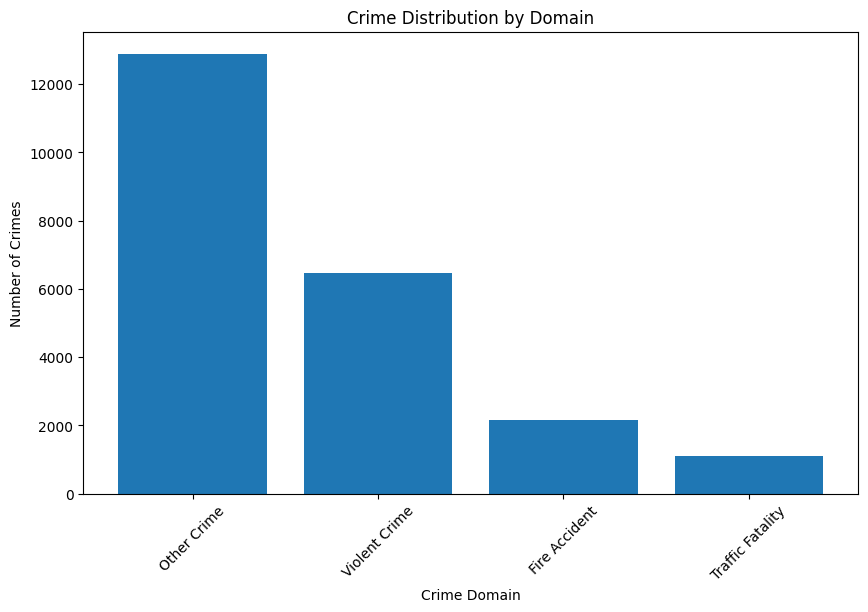

In [21]:
# Crime Distribution by Crime Domain

crime_counts = df['Crime Domain'].value_counts()

plt.figure(figsize=(10,6))
plt.bar(crime_counts.index, crime_counts.values)
plt.xticks(rotation=45)
plt.title("Crime Distribution by Domain")
plt.xlabel("Crime Domain")
plt.ylabel("Number of Crimes")
plt.show()

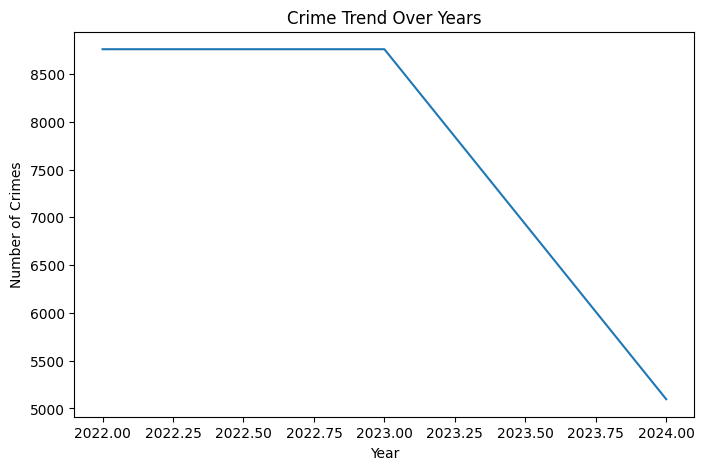

In [22]:
# Crime by Year

year_counts = df['Year'].value_counts().sort_index()

plt.figure(figsize=(8,5))
plt.plot(year_counts.index, year_counts.values)
plt.title("Crime Trend Over Years")
plt.xlabel("Year")
plt.ylabel("Number of Crimes")
plt.show()

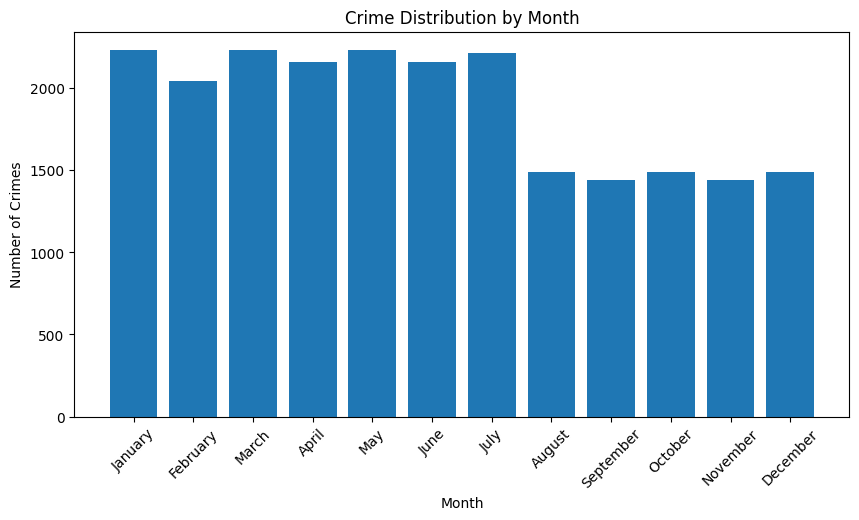

In [23]:
# Crime by Month (Seasonal Analysis)

month_counts = df['Month'].value_counts()

month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']

month_counts = month_counts.reindex(month_order)

plt.figure(figsize=(10,5))
plt.bar(month_counts.index, month_counts.values)
plt.xticks(rotation=45)
plt.title("Crime Distribution by Month")
plt.xlabel("Month")
plt.ylabel("Number of Crimes")
plt.show()


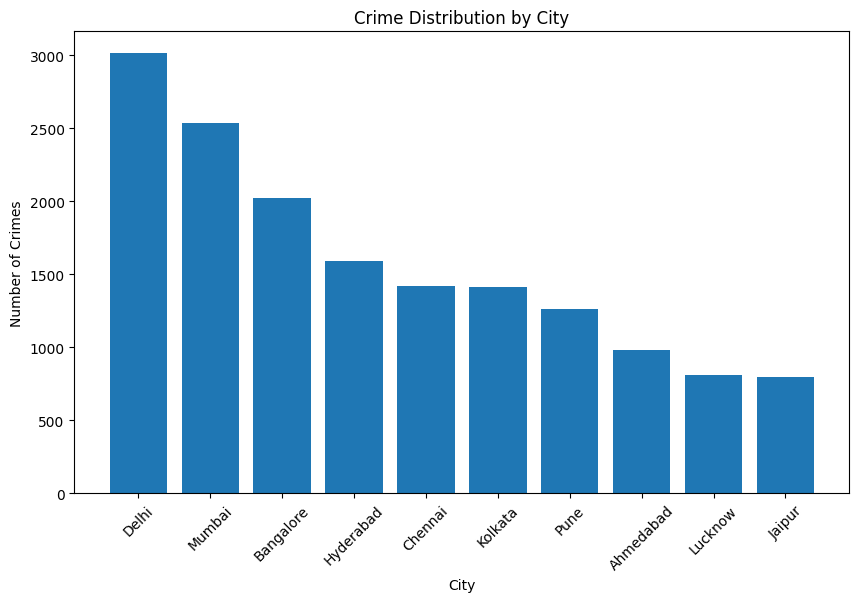

In [24]:
# Crime by City (Top 10)

city_counts = df['City'].value_counts().head(10)

plt.figure(figsize=(10,6))
plt.bar(city_counts.index, city_counts.values)
plt.xticks(rotation=45)
plt.title("Crime Distribution by City")
plt.xlabel("City")
plt.ylabel("Number of Crimes")
plt.show()

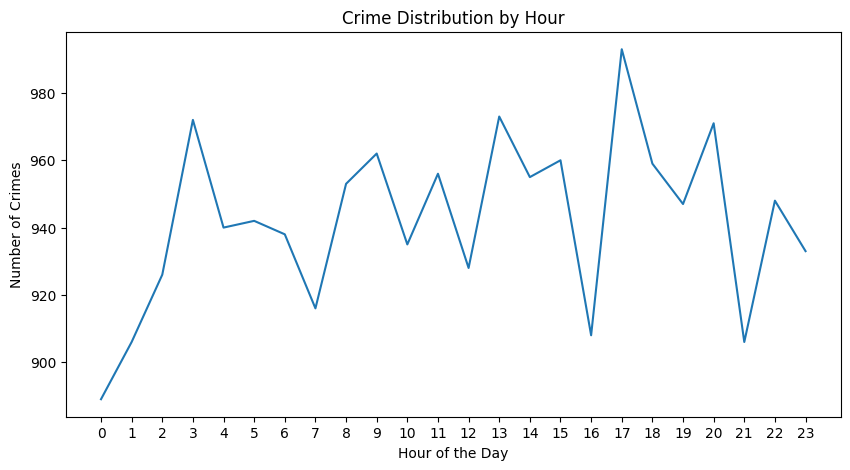

In [25]:
# Crime by Hour of the Day

hour_counts = df['Hour'].value_counts().sort_index()

plt.figure(figsize=(10,5))
plt.plot(hour_counts.index, hour_counts.values)
plt.title("Crime Distribution by Hour")
plt.xlabel("Hour of the Day")
plt.ylabel("Number of Crimes")
plt.xticks(range(0,24))
plt.show()

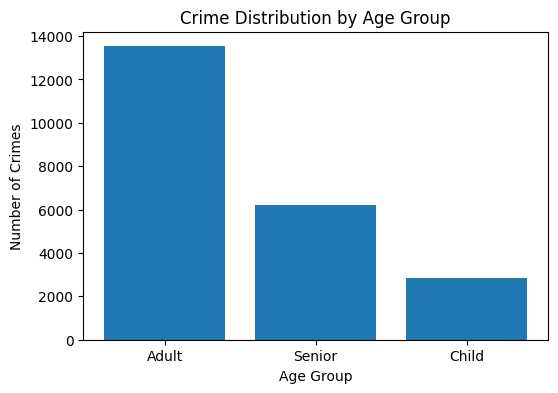

In [26]:
# Crime by Age Group

age_counts = df['Age_Group'].value_counts()

plt.figure(figsize=(6,4))
plt.bar(age_counts.index, age_counts.values)
plt.title("Crime Distribution by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Number of Crimes")
plt.show()

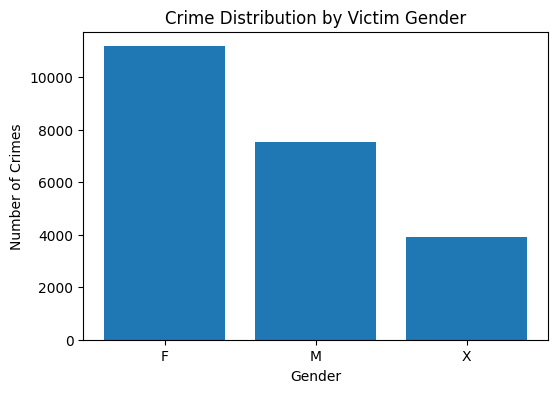

In [27]:
# Victim Gender Analysis

gender_counts = df['Victim Gender'].value_counts()

plt.figure(figsize=(6,4))
plt.bar(gender_counts.index, gender_counts.values)
plt.title("Crime Distribution by Victim Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Crimes")
plt.show()

Crime Domain
Fire Accident        9.984750
Other Crime         10.017530
Traffic Fatality    10.058024
Violent Crime        9.991947
Name: Police Deployed, dtype: float64


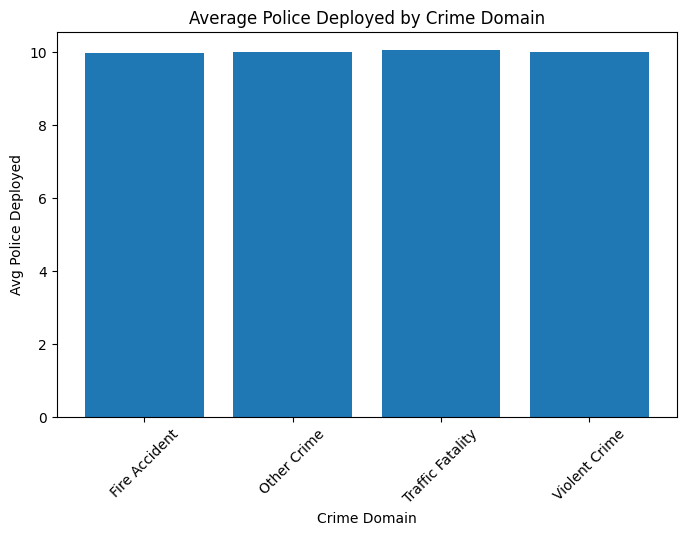

In [28]:
# Police Deployment Efficiency

avg_police_by_domain = df.groupby('Crime Domain')['Police Deployed'].mean()
print(avg_police_by_domain)

plt.figure(figsize=(8,5))
plt.bar(avg_police_by_domain.index, avg_police_by_domain.values)
plt.xticks(rotation=45)
plt.title("Average Police Deployed by Crime Domain")
plt.xlabel("Crime Domain")
plt.ylabel("Avg Police Deployed")
plt.show()